In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.computation.expressions import where

b2b = pd.read_csv("MP_Synthetics_50000_Rows.csv")

In [2]:
df = b2b.copy()

In [3]:
df.head()

,Customer_ID,Company_Name,Industry,Country,Company_Size,Account_Manager,Plan_Tier,Billing_Cycle,Monthly_Recurring_Revenue,Signup_Date,Last_Active_Date,Payment_Status,Active_Seats_Used,Total_Seats_Allowed,Support_Tickets_30d,Feature_Adoption_Rate,Churn_Risk_Score,Is_Churned
0,CUST-1001,Pulse Net 944,HealthTech,Australia,Nov-50,Sarah Jenkins,Starter,Annual,49,12/03/2025,18/02/2026,Active,3,8,5,44%,Low,0
1,CUST-1002,Pulse Logic 332,CyberSecurity,USA,51-200,David Ross,Pro,Annual,499,29/09/2023,25/02/2026,Active,13,24,3,58%,Low,0
2,CUST-1003,Secure Flow 975,DevTools,India,01-Oct,David Ross,Starter,Monthly,79,16/03/2025,19/02/2026,Active,6,8,5,70%,Low,0
3,CUST-1004,Quantum Scale 657,EdTech,Singapore,51-200,Marcus Vance,Pro,Annual,249,05/03/2024,22/02/2026,Active,34,39,2,90%,Low,0
4,CUST-1005,Quantum Sphere 308,E-Commerce,Germany,01-Oct,Aisha Khan,Starter,Monthly,129,28/02/2025,22/02/2026,Active,8,9,3,93%,Low,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Customer_ID                50000 non-null  str  
 1   Company_Name               50000 non-null  str  
 2   Industry                   50000 non-null  str  
 3   Country                    50000 non-null  str  
 4   Company_Size               50000 non-null  str  
 5   Account_Manager            50000 non-null  str  
 6   Plan_Tier                  50000 non-null  str  
 7   Billing_Cycle              50000 non-null  str  
 8   Monthly_Recurring_Revenue  50000 non-null  int64
 9   Signup_Date                50000 non-null  str  
 10  Last_Active_Date           50000 non-null  str  
 11  Payment_Status             50000 non-null  str  
 12  Active_Seats_Used          50000 non-null  int64
 13  Total_Seats_Allowed        50000 non-null  int64
 14  Support_Tickets_30d        50000 

In [5]:
df.describe()

,Monthly_Recurring_Revenue,Active_Seats_Used,Total_Seats_Allowed,Support_Tickets_30d,Is_Churned
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,665.358160,50.843960,73.664360,3.351360,0.018320
std,1592.411168,133.757042,185.526556,1.681904,0.134107
min,49.000000,1.000000,3.000000,0.000000,0.000000
25%,79.000000,3.000000,6.000000,2.000000,0.000000
50%,129.000000,6.000000,9.000000,3.000000,0.000000
75%,299.000000,26.000000,39.000000,5.000000,0.000000
max,8499.000000,976.000000,999.000000,8.000000,1.000000


In [6]:
df.columns

Index(['Customer_ID', 'Company_Name', 'Industry', 'Country', 'Company_Size',
       'Account_Manager', 'Plan_Tier', 'Billing_Cycle',
       'Monthly_Recurring_Revenue', 'Signup_Date', 'Last_Active_Date',
       'Payment_Status', 'Active_Seats_Used', 'Total_Seats_Allowed',
       'Support_Tickets_30d', 'Feature_Adoption_Rate', 'Churn_Risk_Score',
       'Is_Churned'],
      dtype='str')

In [7]:
df["Signup_Date"] = pd.to_datetime(df["Signup_Date"], dayfirst=True)

In [8]:
df["Last_Active_Date"] = pd.to_datetime(df["Last_Active_Date"], dayfirst=True)

In [9]:
df.dtypes

Customer_ID                             str
Company_Name                            str
Industry                                str
Country                                 str
Company_Size                            str
Account_Manager                         str
Plan_Tier                               str
Billing_Cycle                           str
Monthly_Recurring_Revenue             int64
Signup_Date                  datetime64[us]
Last_Active_Date             datetime64[us]
Payment_Status                          str
Active_Seats_Used                     int64
Total_Seats_Allowed                   int64
Support_Tickets_30d                   int64
Feature_Adoption_Rate                   str
Churn_Risk_Score                        str
Is_Churned                            int64
dtype: object

In [10]:
df["Company_Size"]

0        Nov-50
1        51-200
2        01-Oct
3        51-200
4        01-Oct
          ...  
49995    01-Oct
49996    01-Oct
49997    01-Oct
49998    01-Oct
49999    51-200
Name: Company_Size, Length: 50000, dtype: str

In [11]:
df["Company_Size"].value_counts()

Company_Size
01-Oct      21089
51-200      11170
Nov-50       8919
201-500      5508
1000+        1667
501-1000     1647
Name: count, dtype: int64

In [12]:
company_size_map = {
    '01-Oct': '1-10',
    'Oct-01': '1-10',
    'Nov-50': '11-50',
    '51-200': '51-200',
    '201-500': '201-500',
    '500-1000': '1000+'
}

In [13]:
df['Company_Size'] = df['Company_Size'].replace(company_size_map)

In [14]:
df["Company_Size"].value_counts()

Company_Size
1-10        21089
51-200      11170
11-50        8919
201-500      5508
1000+        1667
501-1000     1647
Name: count, dtype: int64

In [15]:
df["Company_Size"]

0         11-50
1        51-200
2          1-10
3        51-200
4          1-10
          ...  
49995      1-10
49996      1-10
49997      1-10
49998      1-10
49999    51-200
Name: Company_Size, Length: 50000, dtype: str

In [16]:
df

,Customer_ID,Company_Name,Industry,Country,Company_Size,Account_Manager,Plan_Tier,Billing_Cycle,Monthly_Recurring_Revenue,Signup_Date,Last_Active_Date,Payment_Status,Active_Seats_Used,Total_Seats_Allowed,Support_Tickets_30d,Feature_Adoption_Rate,Churn_Risk_Score,Is_Churned
0,CUST-1001,Pulse Net 944,HealthTech,Australia,11-50,Sarah Jenkins,Starter,Annual,49,2025-03-12,2026-02-18,Active,3,8,5,44%,Low,0
1,CUST-1002,Pulse Logic 332,CyberSecurity,USA,51-200,David Ross,Pro,Annual,499,2023-09-29,2026-02-25,Active,13,24,3,58%,Low,0
2,CUST-1003,Secure Flow 975,DevTools,India,1-10,David Ross,Starter,Monthly,79,2025-03-16,2026-02-19,Active,6,8,5,70%,Low,0
3,CUST-1004,Quantum Scale 657,EdTech,Singapore,51-200,Marcus Vance,Pro,Annual,249,2024-03-05,2026-02-22,Active,34,39,2,90%,Low,0
4,CUST-1005,Quantum Sphere 308,E-Commerce,Germany,1-10,Aisha Khan,Starter,Monthly,129,2025-02-28,2026-02-22,Active,8,9,3,93%,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST-50996,Omni AI 147,CyberSecurity,Canada,1-10,Aisha Khan,Starter,Annual,129,2025-03-16,2026-02-17,Active,7,10,4,69%,Low,0
49996,CUST-50997,Vibe Logic 456,MarTech,India,1-10,Aisha Khan,Starter,Monthly,49,2024-11-16,2026-02-16,Active,7,8,3,88%,Low,0
49997,CUST-50998,Quantum Net 553,FinTech,UK,1-10,Sarah Jenkins,Starter,Monthly,49,2023-05-12,2026-02-19,Active,5,7,4,88%,Low,0
49998,CUST-50999,Pulse Flow 109,FinTech,France,1-10,David Ross,Starter,Monthly,49,2025-07-25,2026-02-20,Active,6,9,5,64%,Low,0


# Churned accounts by Billing cycle(Annually & Monthly) and Plan Tier

In [17]:
df["Is_Churned"].value_counts()

Is_Churned
0    49084
1      916
Name: count, dtype: int64

In [18]:
no_of_churned = df.groupby(["Plan_Tier", "Billing_Cycle"])["Is_Churned"].sum()

In [19]:
no_of_churned

Plan_Tier   Billing_Cycle
Enterprise  Annual            24
            Monthly           33
Pro         Annual            66
            Monthly          108
Starter     Annual           237
            Monthly          448
Name: Is_Churned, dtype: int64

In [20]:
churn_summary = df.groupby(["Plan_Tier", "Billing_Cycle"]).agg(
    total_customers=('Is_Churned', 'count'),
    churned_customers=('Is_Churned', 'sum'),
    churn_rate=('Is_Churned', 'mean')
).reset_index()

In [21]:
churn_summary['churn_rate_pct'] = (churn_summary['churn_rate'] * 100).round(2)

In [22]:
churn_summary

,Plan_Tier,Billing_Cycle,total_customers,churned_customers,churn_rate,churn_rate_pct
0,Enterprise,Annual,1768,24,0.013575,1.36
1,Enterprise,Monthly,3283,33,0.010052,1.01
2,Pro,Annual,5142,66,0.012835,1.28
3,Pro,Monthly,9799,108,0.011022,1.10
4,Starter,Annual,10557,237,0.022450,2.24
5,Starter,Monthly,19451,448,0.023032,2.30


In [23]:
(churn_summary.sort_values(by='churn_rate_pct', ascending=False))

,Plan_Tier,Billing_Cycle,total_customers,churned_customers,churn_rate,churn_rate_pct
5,Starter,Monthly,19451,448,0.023032,2.30
4,Starter,Annual,10557,237,0.022450,2.24
0,Enterprise,Annual,1768,24,0.013575,1.36
2,Pro,Annual,5142,66,0.012835,1.28
3,Pro,Monthly,9799,108,0.011022,1.10
1,Enterprise,Monthly,3283,33,0.010052,1.01


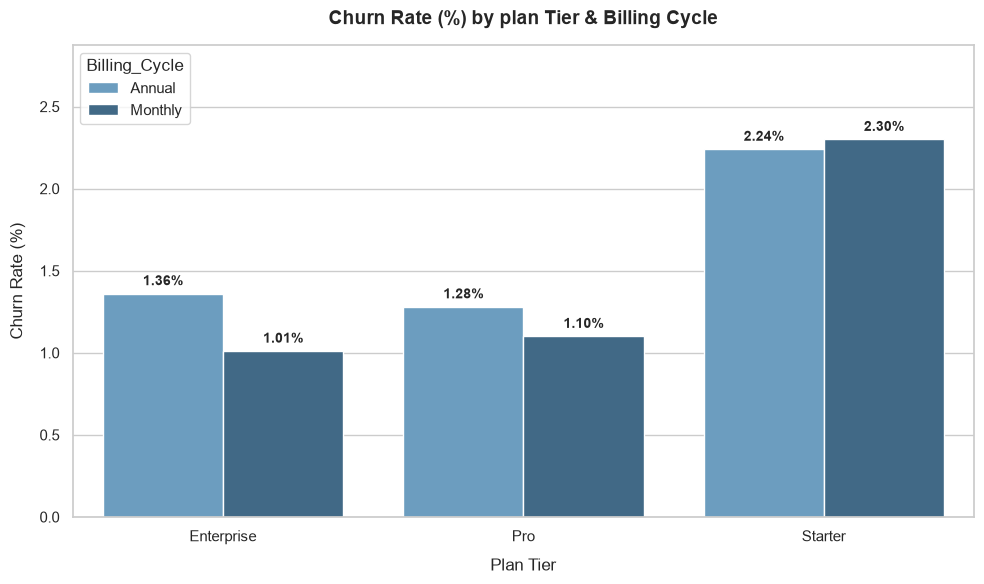

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=churn_summary,
    x="Plan_Tier",
    y="churn_rate_pct",
    hue="Billing_Cycle",
    palette='Blues_d'
)

plt.title('Churn Rate (%) by plan Tier & Billing Cycle', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Plan Tier', fontsize=12, labelpad=10)
plt.ylabel('Churn Rate (%)', fontsize=12, labelpad=10)
plt.ylim(0, churn_summary['churn_rate_pct'].max() * 1.25)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 4), textcoords='offset points',
        )

        plt.tight_layout()

In [25]:
df

,Customer_ID,Company_Name,Industry,Country,Company_Size,Account_Manager,Plan_Tier,Billing_Cycle,Monthly_Recurring_Revenue,Signup_Date,Last_Active_Date,Payment_Status,Active_Seats_Used,Total_Seats_Allowed,Support_Tickets_30d,Feature_Adoption_Rate,Churn_Risk_Score,Is_Churned
0,CUST-1001,Pulse Net 944,HealthTech,Australia,11-50,Sarah Jenkins,Starter,Annual,49,2025-03-12,2026-02-18,Active,3,8,5,44%,Low,0
1,CUST-1002,Pulse Logic 332,CyberSecurity,USA,51-200,David Ross,Pro,Annual,499,2023-09-29,2026-02-25,Active,13,24,3,58%,Low,0
2,CUST-1003,Secure Flow 975,DevTools,India,1-10,David Ross,Starter,Monthly,79,2025-03-16,2026-02-19,Active,6,8,5,70%,Low,0
3,CUST-1004,Quantum Scale 657,EdTech,Singapore,51-200,Marcus Vance,Pro,Annual,249,2024-03-05,2026-02-22,Active,34,39,2,90%,Low,0
4,CUST-1005,Quantum Sphere 308,E-Commerce,Germany,1-10,Aisha Khan,Starter,Monthly,129,2025-02-28,2026-02-22,Active,8,9,3,93%,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST-50996,Omni AI 147,CyberSecurity,Canada,1-10,Aisha Khan,Starter,Annual,129,2025-03-16,2026-02-17,Active,7,10,4,69%,Low,0
49996,CUST-50997,Vibe Logic 456,MarTech,India,1-10,Aisha Khan,Starter,Monthly,49,2024-11-16,2026-02-16,Active,7,8,3,88%,Low,0
49997,CUST-50998,Quantum Net 553,FinTech,UK,1-10,Sarah Jenkins,Starter,Monthly,49,2023-05-12,2026-02-19,Active,5,7,4,88%,Low,0
49998,CUST-50999,Pulse Flow 109,FinTech,France,1-10,David Ross,Starter,Monthly,49,2025-07-25,2026-02-20,Active,6,9,5,64%,Low,0


# Ticket Support in past 30 days and how it affects churn

In [26]:
ticket_summary = df.groupby(["Support_Tickets_30d"]).agg(
    total_customers=('Is_Churned', 'count'),
    churned_customers=('Is_Churned', 'sum'),
    churn_rate=('Is_Churned', 'mean')
).reset_index()

In [27]:
ticket_summary

,Support_Tickets_30d,total_customers,churned_customers,churn_rate
0,0,2216,1,0.000451
1,1,5161,12,0.002325
2,2,8274,28,0.003384
3,3,11179,110,0.009840
4,4,10412,170,0.016327
5,5,7265,232,0.031934
6,6,4153,231,0.055622
7,7,1289,124,0.096199
8,8,51,8,0.156863


In [28]:
ticket_summary['churn_rate_pct'] = (ticket_summary['churn_rate'] * 100).round(2)

In [29]:
ticket_summary['churn_rate_pct']

0     0.05
1     0.23
2     0.34
3     0.98
4     1.63
5     3.19
6     5.56
7     9.62
8    15.69
Name: churn_rate_pct, dtype: float64

In [30]:
df["Support_Tickets_30d"].value_counts()

Support_Tickets_30d
3    11179
4    10412
2     8274
5     7265
1     5161
6     4153
0     2216
7     1289
8       51
Name: count, dtype: int64

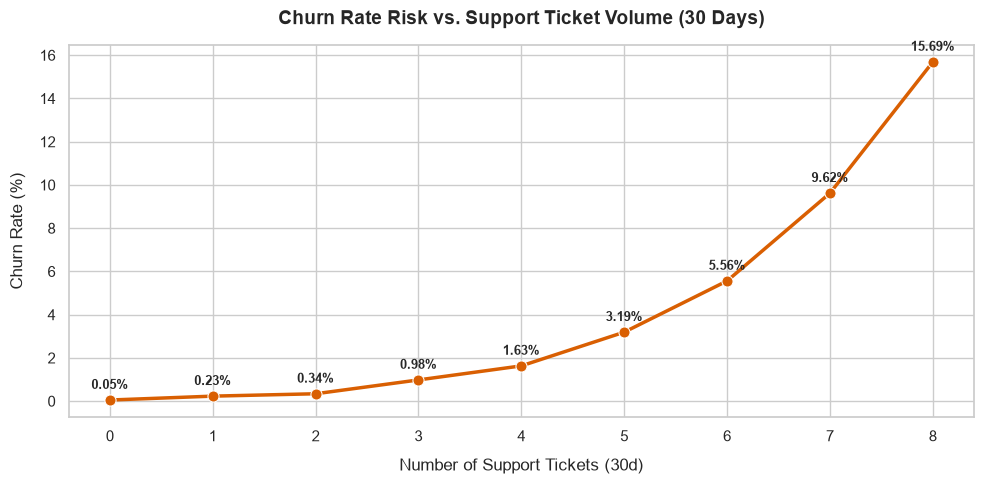

In [31]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=ticket_summary,
    x='Support_Tickets_30d',
    y='churn_rate_pct',
    marker='o',
    markersize=8,
    color='#d95f02',
    linewidth=2.5
)

plt.title('Churn Rate Risk vs. Support Ticket Volume (30 Days)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Support Tickets (30d)', fontsize=12, labelpad=10)
plt.ylabel('Churn Rate (%)', fontsize=12, labelpad=10)
plt.xticks(ticket_summary['Support_Tickets_30d'])

for index, row in ticket_summary.iterrows():
    ax.annotate(
        f"{row['churn_rate_pct']:.2f}%",
        (row['Support_Tickets_30d'], row['churn_rate_pct']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()

# Seat usage and how it affects churn

In [32]:
df.columns

Index(['Customer_ID', 'Company_Name', 'Industry', 'Country', 'Company_Size',
       'Account_Manager', 'Plan_Tier', 'Billing_Cycle',
       'Monthly_Recurring_Revenue', 'Signup_Date', 'Last_Active_Date',
       'Payment_Status', 'Active_Seats_Used', 'Total_Seats_Allowed',
       'Support_Tickets_30d', 'Feature_Adoption_Rate', 'Churn_Risk_Score',
       'Is_Churned'],
      dtype='str')

In [33]:
df['Seat_Utilization'] = df['Active_Seats_Used'] / df['Total_Seats_Allowed']

In [34]:
df['Utilization_Tier'] = pd.cut(
    df['Seat_Utilization'],
    bins=[-0.01, 0.30, 0.70, 1.0],
    labels=['Low (<30)', 'Medium (30-70%)', 'High (>70%)']
)

In [35]:
seat_utilization_summary = df.groupby(["Utilization_Tier"]).agg(
    total_customers=('Is_Churned', 'count'),
    churned_customers=('Is_Churned', 'sum'),
    churn_rate=('Is_Churned', 'mean')
).reset_index()

In [36]:
seat_utilization_summary

,Utilization_Tier,total_customers,churned_customers,churn_rate
0,Low (<30),819,65,0.079365
1,Medium (30-70%),29819,793,0.026594
2,High (>70%),19362,58,0.002996


In [37]:
# Assuming your summary DataFrame is named util_summary
seat_utilization_summary['churn_rate_pct'] = (seat_utilization_summary['churn_rate'] * 100).round(2)

C:\Users\HomePC\AppData\Local\Temp\ipykernel_2184\1039106680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


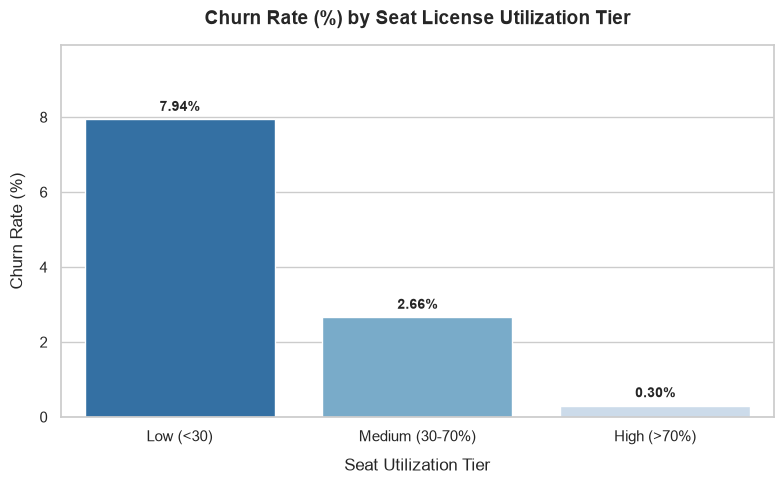

In [38]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Create bar chart
ax = sns.barplot(
    data=seat_utilization_summary,
    x='Utilization_Tier',
    y='churn_rate_pct',
    palette='Blues_r'
)

plt.title('Churn Rate (%) by Seat License Utilization Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Seat Utilization Tier', fontsize=12, labelpad=10)
plt.ylabel('Churn Rate (%)', fontsize=12, labelpad=10)
plt.ylim(0, seat_utilization_summary['churn_rate_pct'].max() * 1.25)

# Add data labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 4), textcoords='offset points'
        )

plt.tight_layout()

In [39]:
df

,Customer_ID,Company_Name,Industry,Country,Company_Size,Account_Manager,Plan_Tier,Billing_Cycle,Monthly_Recurring_Revenue,Signup_Date,Last_Active_Date,Payment_Status,Active_Seats_Used,Total_Seats_Allowed,Support_Tickets_30d,Feature_Adoption_Rate,Churn_Risk_Score,Is_Churned,Seat_Utilization,Utilization_Tier
0,CUST-1001,Pulse Net 944,HealthTech,Australia,11-50,Sarah Jenkins,Starter,Annual,49,2025-03-12,2026-02-18,Active,3,8,5,44%,Low,0,0.375000,Medium (30-70%)
1,CUST-1002,Pulse Logic 332,CyberSecurity,USA,51-200,David Ross,Pro,Annual,499,2023-09-29,2026-02-25,Active,13,24,3,58%,Low,0,0.541667,Medium (30-70%)
2,CUST-1003,Secure Flow 975,DevTools,India,1-10,David Ross,Starter,Monthly,79,2025-03-16,2026-02-19,Active,6,8,5,70%,Low,0,0.750000,High (>70%)
3,CUST-1004,Quantum Scale 657,EdTech,Singapore,51-200,Marcus Vance,Pro,Annual,249,2024-03-05,2026-02-22,Active,34,39,2,90%,Low,0,0.871795,High (>70%)
4,CUST-1005,Quantum Sphere 308,E-Commerce,Germany,1-10,Aisha Khan,Starter,Monthly,129,2025-02-28,2026-02-22,Active,8,9,3,93%,Low,0,0.888889,High (>70%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST-50996,Omni AI 147,CyberSecurity,Canada,1-10,Aisha Khan,Starter,Annual,129,2025-03-16,2026-02-17,Active,7,10,4,69%,Low,0,0.700000,Medium (30-70%)
49996,CUST-50997,Vibe Logic 456,MarTech,India,1-10,Aisha Khan,Starter,Monthly,49,2024-11-16,2026-02-16,Active,7,8,3,88%,Low,0,0.875000,High (>70%)
49997,CUST-50998,Quantum Net 553,FinTech,UK,1-10,Sarah Jenkins,Starter,Monthly,49,2023-05-12,2026-02-19,Active,5,7,4,88%,Low,0,0.714286,High (>70%)
49998,CUST-50999,Pulse Flow 109,FinTech,France,1-10,David Ross,Starter,Monthly,49,2025-07-25,2026-02-20,Active,6,9,5,64%,Low,0,0.666667,Medium (30-70%)


# Feature Adoption rate in relation to churn

In [40]:
feature_summary = df.groupby('Feature_Adoption_Rate').agg(
    total_customers=('Is_Churned', 'count'),
    churned_customers=('Is_Churned', 'sum'),
    churn_rate=('Is_Churned', 'mean')
).reset_index()

In [41]:
df['Adoption_Score_Clean'] = (
    df['Feature_Adoption_Rate']
    .astype(str)
    .str.rstrip('%')
    .astype(float)
)

In [42]:
df['Adoption_Tier'] = pd.cut(
    df['Adoption_Score_Clean'],
    bins=[-0.1, 50, 80, 100],
    labels=['Low (<50%)', 'Medium (50-80%)', 'High (>80%)']
)

In [43]:
feature_tier_summary = df.groupby('Adoption_Tier').agg(
    total_customers=('Is_Churned', 'count'),
    churned_customers=('Is_Churned', 'sum'),
    churn_rate=('Is_Churned', 'mean')
).reset_index()

feature_tier_summary['churn_rate_pct'] = (feature_tier_summary['churn_rate'] * 100).round(2)
feature_tier_summary

,Adoption_Tier,total_customers,churned_customers,churn_rate,churn_rate_pct
0,Low (<50%),8900,475,0.053371,5.34
1,Medium (50-80%),24884,400,0.016075,1.61
2,High (>80%),16216,41,0.002528,0.25


C:\Users\HomePC\AppData\Local\Temp\ipykernel_2184\852766218.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


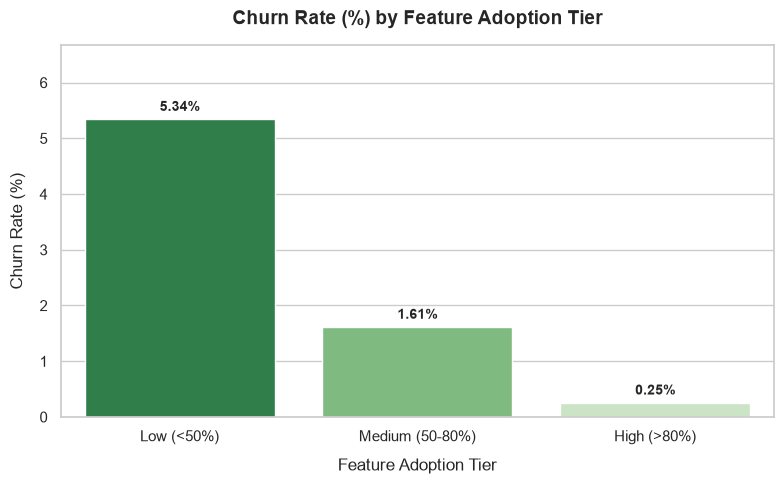

In [44]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=feature_tier_summary,
    x='Adoption_Tier',
    y='churn_rate_pct',
    palette='Greens_r'
)

plt.title('Churn Rate (%) by Feature Adoption Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Feature Adoption Tier', fontsize=12, labelpad=10)
plt.ylabel('Churn Rate (%)', fontsize=12, labelpad=10)
plt.ylim(0, feature_tier_summary['churn_rate_pct'].max() * 1.25)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 4), textcoords='offset points'
        )

plt.tight_layout()

In [45]:
df.columns

Index(['Customer_ID', 'Company_Name', 'Industry', 'Country', 'Company_Size',
       'Account_Manager', 'Plan_Tier', 'Billing_Cycle',
       'Monthly_Recurring_Revenue', 'Signup_Date', 'Last_Active_Date',
       'Payment_Status', 'Active_Seats_Used', 'Total_Seats_Allowed',
       'Support_Tickets_30d', 'Feature_Adoption_Rate', 'Churn_Risk_Score',
       'Is_Churned', 'Seat_Utilization', 'Utilization_Tier',
       'Adoption_Score_Clean', 'Adoption_Tier'],
      dtype='str')

# Industry producing the highest MRR

In [46]:
mrr_summary = df.groupby('Industry')['Monthly_Recurring_Revenue'].sum().reset_index().sort_values(by='Monthly_Recurring_Revenue', ascending=False)

In [47]:
mrr_summary

,Industry,Monthly_Recurring_Revenue
0,CyberSecurity,4346064
6,Logistics,4287508
3,EdTech,4265324
4,FinTech,4222265
5,HealthTech,4152494
2,E-Commerce,4034063
1,DevTools,4011427
7,MarTech,3948763


In [48]:
Lost_MRR = df[df['Is_Churned'] == 1].groupby('Industry')['Monthly_Recurring_Revenue'].sum().reset_index().sort_values(by='Monthly_Recurring_Revenue', ascending=False)

In [49]:
Lost_MRR

,Industry,Monthly_Recurring_Revenue
7,MarTech,67748
3,EdTech,66608
1,DevTools,57015
6,Logistics,46469
0,CyberSecurity,42513
5,HealthTech,39733
2,E-Commerce,39054
4,FinTech,36900


C:\Users\HomePC\AppData\Local\Temp\ipykernel_2184\1707452007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


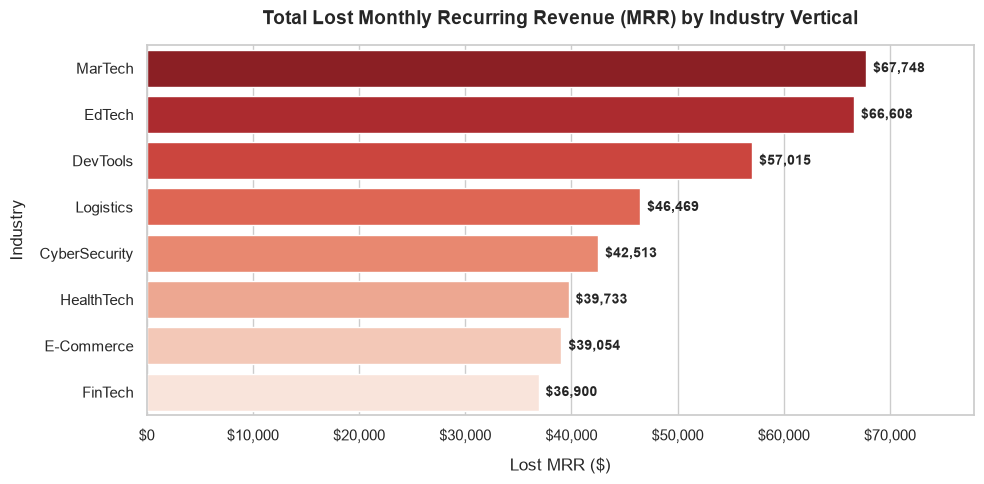

In [51]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Create bar plot for lost MRR by industry
ax = sns.barplot(
    data=Lost_MRR,
    x='Monthly_Recurring_Revenue',
    y='Industry',
    palette='Reds_r'
)

plt.title('Total Lost Monthly Recurring Revenue (MRR) by Industry Vertical', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Lost MRR ($)', fontsize=12, labelpad=10)
plt.ylabel('Industry', fontsize=12, labelpad=10)

# Format x-axis labels with commas ($60,000)
ax.xaxis.set_major_formatter('${x:,.0f}')

# Add data labels on the bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'${width:,.0f}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(5, 0), textcoords='offset points'
        )

plt.xlim(0, Lost_MRR['Monthly_Recurring_Revenue'].max() * 1.15)
plt.tight_layout()